In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.api as sm

In [4]:
df = pd.read_csv('Superstore.csv')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Preprocessing

In [6]:
print("Dataset Shape:", df.shape)
print("Column Names:\n", df.columns.tolist())

Dataset Shape: (9994, 21)
Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [7]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [8]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

In [9]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

# Furniture Forecasting

In [13]:
furniture = df.loc[df['Category']== 'Furniture']

In [14]:
furniture.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
10,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [15]:
furniture.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [16]:
r_col = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Quantity', 'Discount', 'Profit']

In [17]:
furniture.drop(r_col, axis =1 , inplace=True)

C:\Users\01\AppData\Local\Temp\ipykernel_8096\1656065309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furniture.drop(r_col, axis =1 , inplace=True)


In [18]:
furniture

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
3,2015-10-11,957.5775
5,2014-06-09,48.8600
10,2014-06-09,1706.1840
...,...,...
9962,2015-03-19,383.4656
9964,2016-12-05,13.4000
9980,2015-09-06,85.9800
9989,2014-01-21,25.2480


In [19]:
furniture = furniture.sort_values('Order Date')

print("Sorted Order date :")
furniture

Sorted Order date :


,Order Date,Sales
7474,2014-01-06,2573.820
7660,2014-01-07,76.728
866,2014-01-10,51.940
716,2014-01-11,9.940
2978,2014-01-13,545.940
...,...,...
7636,2017-12-29,258.750
7632,2017-12-29,1207.840
5131,2017-12-29,101.120
7635,2017-12-29,300.980


In [20]:
furniture  = furniture.set_index('Order Date')
furniture.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2014-01-06 to 2017-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   2121 non-null   float64
dtypes: float64(1)
memory usage: 33.1 KB


In [21]:
furniture_y = furniture['Sales'].resample('MS').mean()
# MS = Month Start frequency

In [22]:
furniture_y

Order Date
2014-01-01    312.126250
2014-02-01    262.808286
2014-03-01    441.635030
2014-04-01    305.570654
2014-05-01    288.032792
2014-06-01    440.204187
2014-07-01    327.910636
2014-08-01    305.014438
2014-09-01    425.294300
2014-10-01    384.507719
2014-11-01    347.820527
2014-12-01    414.134682
2015-01-01    782.662773
2015-02-01    284.943091
2015-03-01    446.420821
2015-04-01    317.445409
2015-05-01    312.498350
2015-06-01    296.699192
2015-07-01    341.860500
2015-08-01    301.206006
2015-09-01    437.883717
2015-10-01    334.072875
2015-11-01    401.049773
2015-12-01    360.715925
2016-01-01    346.488318
2016-02-01    206.607947
2016-03-01    312.221756
2016-04-01    377.488286
2016-05-01    351.624070
2016-06-01    343.962421
2016-07-01    335.090231
2016-08-01    430.456286
2016-09-01    328.468445
2016-10-01    247.345354
2016-11-01    392.390479
2016-12-01    436.651369
2017-01-01    248.501333
2017-02-01    264.089900
2017-03-01    286.669600
2017-04-01    

In [23]:
furniture_y.head()

Order Date
2014-01-01    312.126250
2014-02-01    262.808286
2014-03-01    441.635030
2014-04-01    305.570654
2014-05-01    288.032792
Freq: MS, Name: Sales, dtype: float64

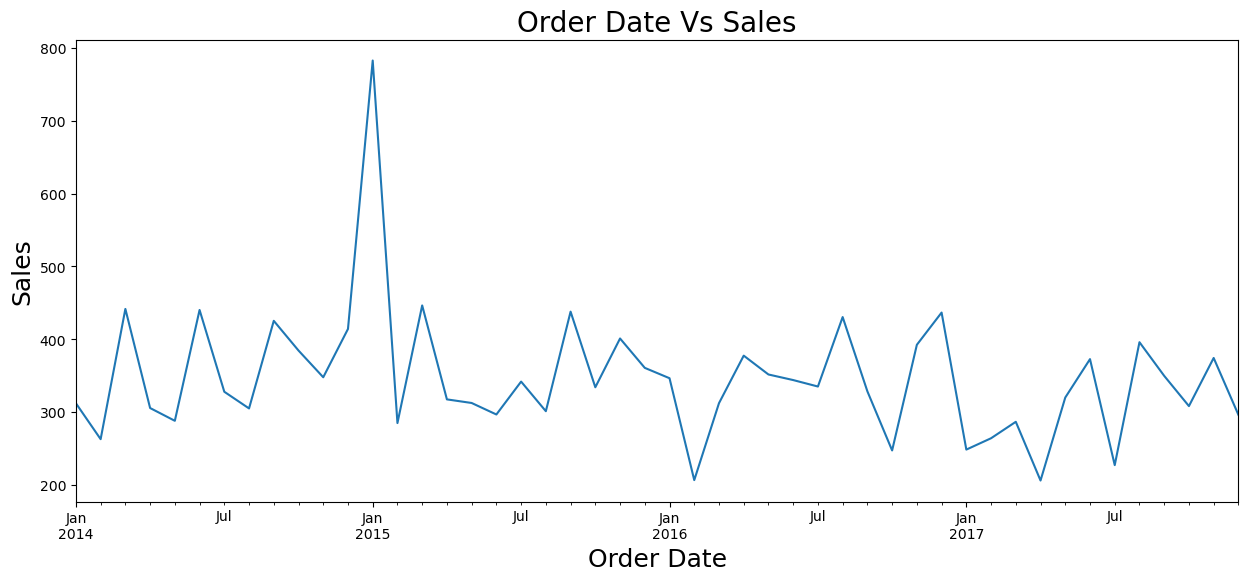

In [24]:
#Trend in sales over year

furniture_y.plot(figsize=(15,6))
plt.ylabel("Sales",fontsize=18)
plt.xlabel("Order Date",fontsize=18)
plt.title("Order Date Vs Sales",fontsize=20)
plt.show()

In [25]:
# seasonal_decomposition 
decomposition = sm.tsa.seasonal_decompose(furniture_y,model='additive')

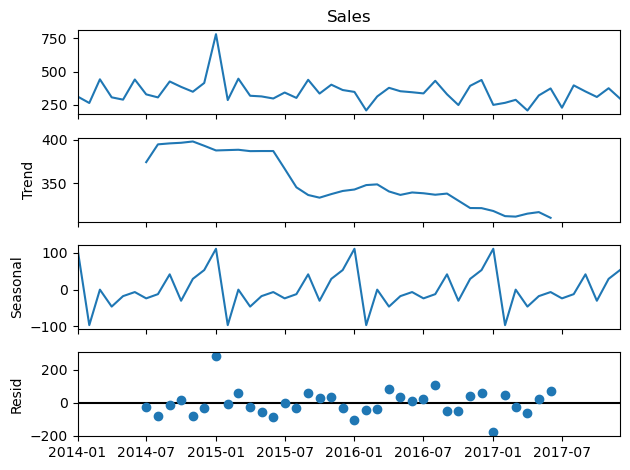

In [26]:
fig = decomposition.plot()
plt.show()

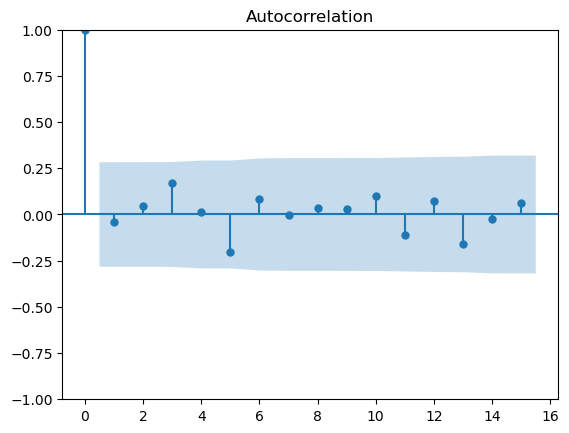

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(furniture_y, lags=15)
plt.show()

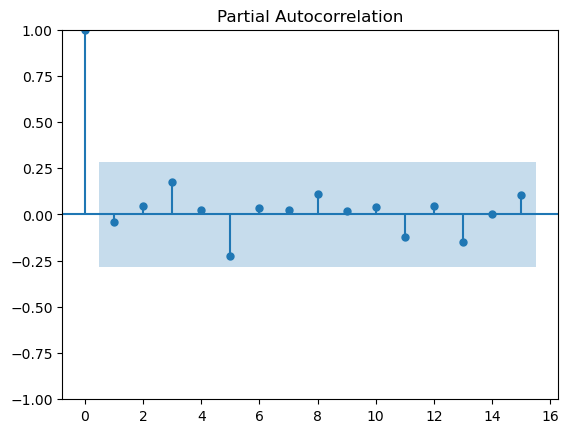

In [28]:
plot_pacf(furniture_y, lags=15)
plt.show()

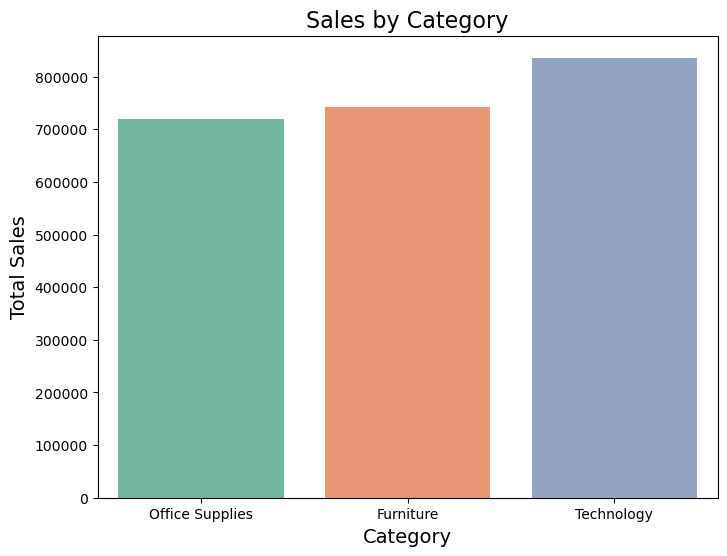

          Category        Sales
0  Office Supplies  719047.0320
1        Furniture  741999.7953
2       Technology  836154.0330


In [29]:
# Category-wise Sales
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=True).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=category_sales, x="Category", y="Sales", hue="Category", palette="Set2", legend=False)

plt.title("Sales by Category", fontsize=16)
plt.xlabel("Category", fontsize=14)
plt.ylabel("Total Sales", fontsize=14)
plt.show()

print(category_sales)

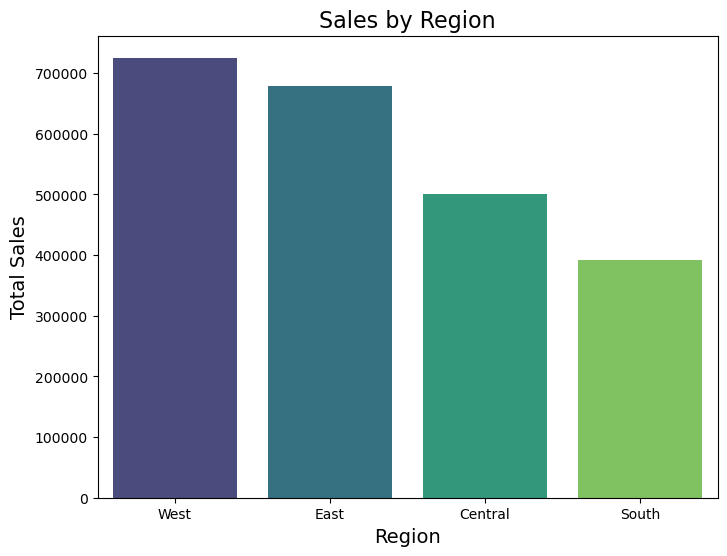

    Region        Sales
0     West  725457.8245
1     East  678781.2400
2  Central  501239.8908
3    South  391721.9050


In [30]:
# Region-wise Sales
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=region_sales, x="Region", y="Sales", hue="Region", palette="viridis", legend=False)

plt.title("Sales by Region", fontsize=16)
plt.xlabel("Region", fontsize=14)
plt.ylabel("Total Sales", fontsize=14)
plt.show()

print(region_sales)

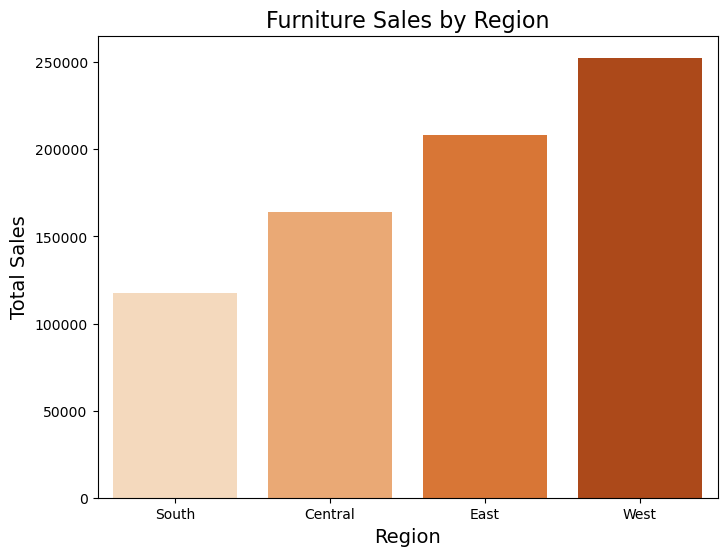

    Region        Sales
0    South  117298.6840
1  Central  163797.1638
2     East  208291.2040
3     West  252612.7435


In [31]:
# Filter only Furniture category
furniture_region_sales = (
    df[df["Category"] == "Furniture"].groupby("Region")["Sales"].sum().sort_values(ascending=True).reset_index()
)

plt.figure(figsize=(8,6))
sns.barplot(data=furniture_region_sales, x="Region", y="Sales", hue="Region", palette="Oranges", legend=False)

plt.title("Furniture Sales by Region", fontsize=16)
plt.xlabel("Region", fontsize=14)
plt.ylabel("Total Sales", fontsize=14)
plt.show()

print(furniture_region_sales)

## Forecasting With SARIMAX

In [32]:
p=d=q=range(0,2)

In [33]:
p,d,q

(range(0, 2), range(0, 2), range(0, 2))

In [34]:
pdq = list(itertools.product(p,d,q))

In [35]:
pdq

[(0, 0, 0),
 (0, 0, 1),
 (0, 1, 0),
 (0, 1, 1),
 (1, 0, 0),
 (1, 0, 1),
 (1, 1, 0),
 (1, 1, 1)]

In [36]:
seasonal_pdq = [(x[1],x[1],x[1], 12) for x in pdq]

In [37]:
seasonal_pdq

[(0, 0, 0, 12),
 (0, 0, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 1, 12),
 (0, 0, 0, 12),
 (0, 0, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 1, 12)]

In [38]:
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(furniture_y,order = param, seasonal_order = param_seasonal ,
                                            enforce_stationarity= False , enforce_invertibility= False )
            results = mod.fit()
            
            print('ARIMA{} x {} 12 -- AIC : {}'.format(param, param_seasonal, results.aic))
            
        except:
             continue

ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 688.3112416991725
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 688.3112416991725
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 274.0919845632806


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 274.0919845632806
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 688.3112416991725
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 688.3112416991725
ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 274.0919845632806


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 274.0919845632806
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 641.1240680666153
ARIMA(0, 0, 1) x (0, 0, 0, 12) 12 -- AIC : 641.1240680666153


...

ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 254.64207132034164
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 540.6257368397359
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 540.6257368397359


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 254.64207132034164


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 254.64207132034164


In [39]:
mod = sm.tsa.statespace.SARIMAX(furniture_y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0771      0.259     -0.298      0.766      -0.584       0.430
ma.L1         -1.0000      0.434     -2.305      0.021      -1.850      -0.150
ar.S.L12      -0.0007      0.029     -0.025      0.980      -0.057       0.056
sigma2      6323.9743   6.86e-05   9.22e+07      0.000    6323.974    6323.974


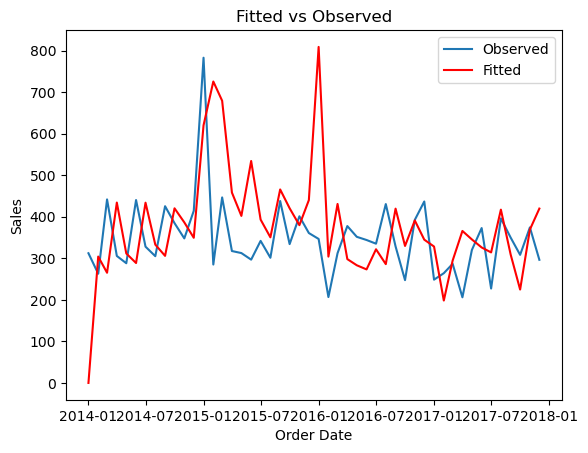

In [40]:
plt.plot(furniture_y, label='Observed')
plt.plot(results.fittedvalues, label='Fitted', color='red')
plt.title('Fitted vs Observed')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [41]:
pr = results.get_prediction(start = pd.to_datetime('2017-01-01'), dynamic = False)
pr.conf_int()

,lower Sales,upper Sales
Order Date,,
2017-01-01,169.078601,487.339126
2017-02-01,39.270051,357.267694
2017-03-01,135.605705,453.360803
2017-04-01,206.959329,524.489949
2017-05-01,186.670997,503.993258
2017-06-01,167.435191,484.563537
2017-07-01,155.609307,472.556729
2017-08-01,258.666941,575.445168
2017-09-01,150.591733,467.211388


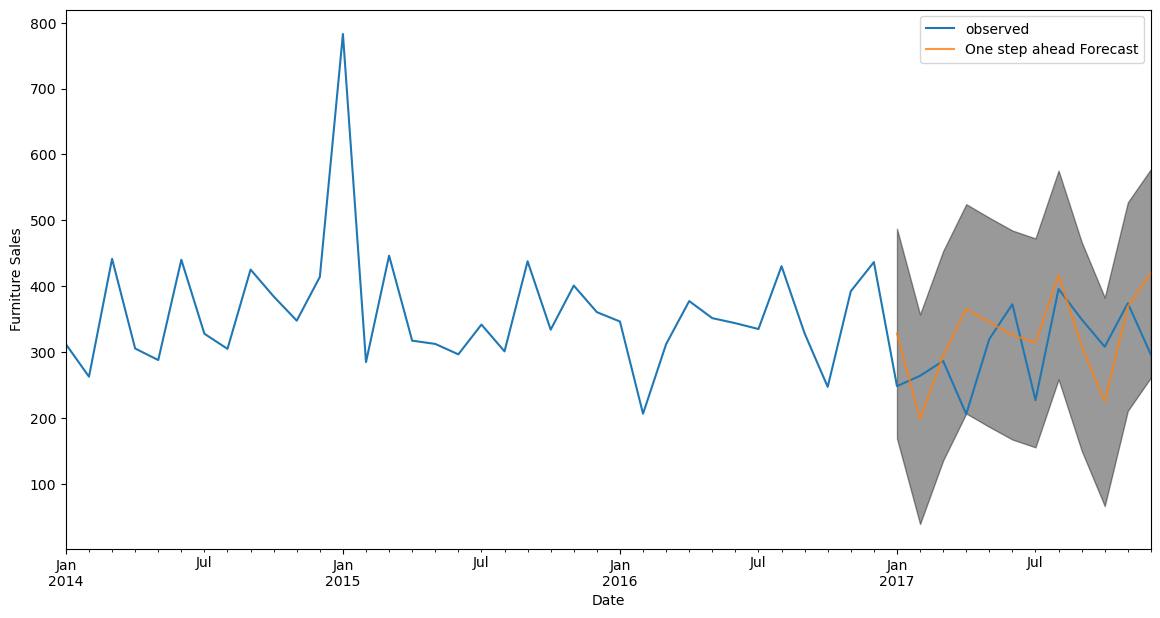

In [42]:
pred = results.get_prediction(start = pd.to_datetime('2017-01-01'), dynamic = False)
pred_ci = pred.conf_int()

ax = furniture_y['2014':].plot(label= 'observed')

pred.predicted_mean.plot(ax = ax, label = 'One step ahead Forecast',
                        alpha = 0.8, figsize= (14,7))

ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color = 'k', alpha= 0.4)

ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')
plt.legend()

plt.show()

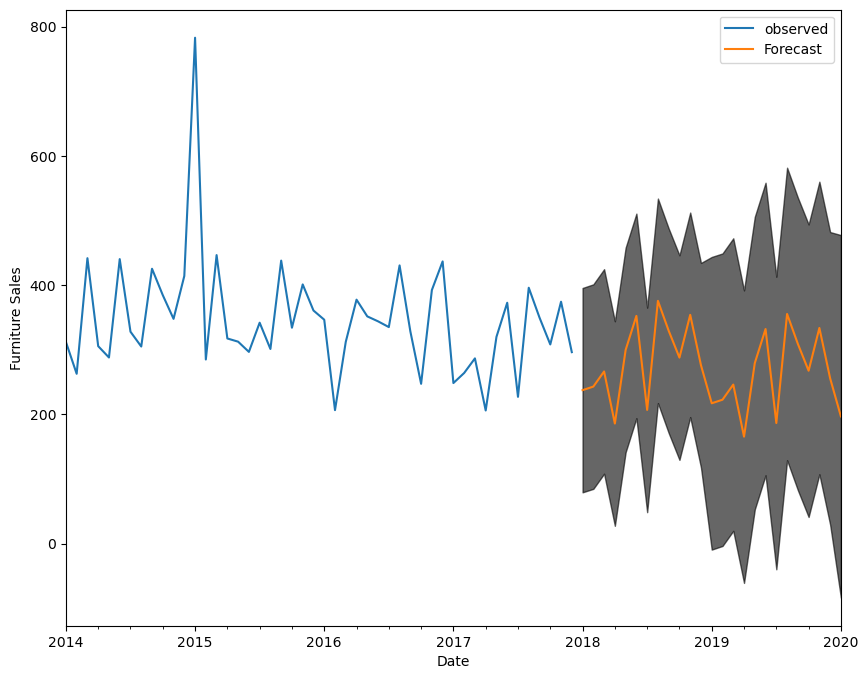

In [43]:
pred_uc = results.get_forecast(steps = 25)
pred_ci = pred_uc.conf_int()

ax = furniture_y.plot(label='observed', figsize=(10,8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')

ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')

plt.legend()
plt.show()

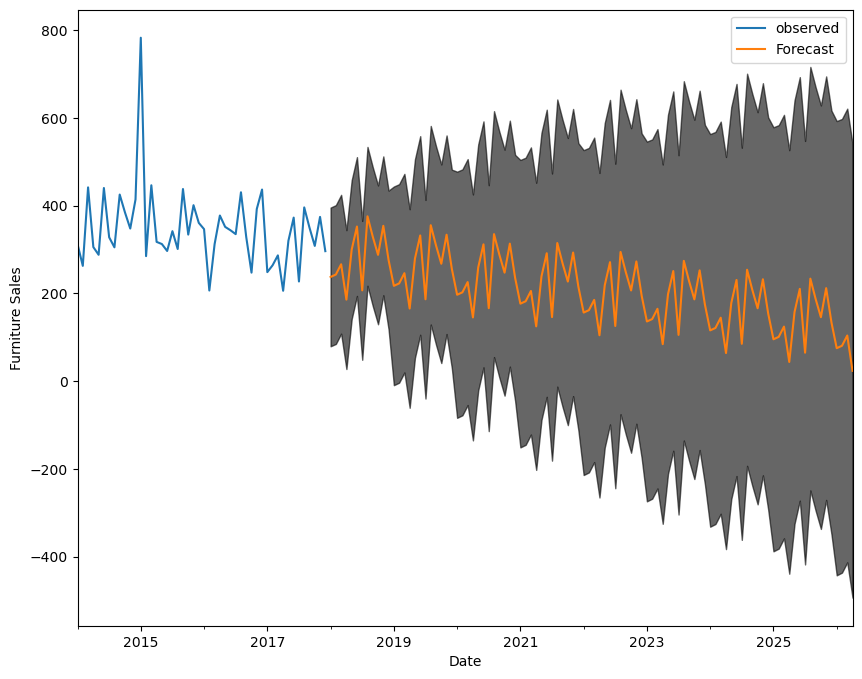

In [44]:
pred_uc = results.get_forecast(steps = 100)
pred_ci = pred_uc.conf_int()

ax = furniture_y.plot(label='observed', figsize=(10,8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
               pred_ci.iloc[:,0],
               pred_ci.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Furniture Sales')

plt.legend()
plt.show()

## Forcasting Values

In [45]:
pred_f = results.get_forecast(steps=100)
pred_furniture = pred_f.predicted_mean
print(pred_furniture)  

2018-01-01    237.515873
2018-02-01    243.026405
2018-03-01    266.433864
2018-04-01    185.853264
2018-05-01    299.667834
                 ...    
2025-12-01    134.026093
2026-01-01     75.153148
2026-02-01     80.670844
2026-03-01    104.077714
2026-04-01     23.497083
Freq: MS, Name: predicted_mean, Length: 100, dtype: float64


In [46]:
# Create future dates
future_dates = pd.date_range(start=furniture_y.index[-1], periods=100+1, freq='M')[1:]

C:\Users\01\AppData\Local\Temp\ipykernel_8096\740783104.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=furniture_y.index[-1], periods=100+1, freq='M')[1:]


In [47]:
print(future_dates)

DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31',
               '2019-01-31', '2019-02-28', '2019-03-31', '2019-04-30',
               '2019-05-31', '2019-06-30', '2019-07-31', '2019-08-31',
               '2019-09-30', '2019-10-31', '2019-11-30', '2019-12-31',
               '2020-01-31', '2020-02-29', '2020-03-31', '2020-04-30',
               '2020-05-31', '2020-06-30', '2020-07-31', '2020-08-31',
               '2020-09-30', '2020-10-31', '2020-11-30', '2020-12-31',
               '2021-01-31', '2021-02-28', '2021-03-31', '2021-04-30',
               '2021-05-31', '2021-06-30', '2021-07-31', '2021-08-31',
               '2021-09-30', '2021-10-31', '2021-11-30', '2021-12-31',
               '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
      

In [48]:
# Convert forecast to DataFrame
forecast_furniture = pd.DataFrame({'Order Date': future_dates, 'Sales': pred_furniture.values})
print(forecast_furniture)

   Order Date       Sales
0  2018-01-31  237.515873
1  2018-02-28  243.026405
2  2018-03-31  266.433864
3  2018-04-30  185.853264
4  2018-05-31  299.667834
..        ...         ...
95 2025-12-31  134.026093
96 2026-01-31   75.153148
97 2026-02-28   80.670844
98 2026-03-31  104.077714
99 2026-04-30   23.497083

[100 rows x 2 columns]


In [49]:
# Save forecast to CSV
forecast_furniture.to_csv("furniture_forcast.csv", index=False)

In [50]:
furniture_y.to_csv("furniture.csv", index=True)

# Office Supplies Forecast

In [62]:
o_s=df.loc[df['Category']== 'Office Supplies']

In [63]:
o_s.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
6,7,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
8,9,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825
9,10,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5,0.0,34.4700


In [64]:
o_s_col = ['Row ID', 'Order ID', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Quantity', 'Discount', 'Profit']

In [65]:
o_s.drop(o_s_col, axis =1 , inplace=True)

C:\Users\01\AppData\Local\Temp\ipykernel_8096\1146265735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o_s.drop(o_s_col, axis =1 , inplace=True)


In [66]:
o_s

,Order Date,Sales
2,2016-06-12,14.620
4,2015-10-11,22.368
6,2014-06-09,7.280
8,2014-06-09,18.504
9,2014-06-09,114.900
...,...,...
9982,2016-09-22,35.560
9984,2015-05-17,31.500
9985,2015-05-17,55.600
9992,2017-02-26,29.600


In [67]:
os = o_s.sort_values('Order Date')
os = os.set_index('Order Date')

In [68]:
os

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,272.736
2014-01-04,11.784
2014-01-04,3.540
2014-01-05,19.536
...,...
2017-12-30,3.024
2017-12-30,20.720
2017-12-30,52.776


In [70]:
os_y = os['Sales'].resample('MS').mean()

In [71]:
os_y.head()

Order Date
2014-01-01     97.021600
2014-02-01     34.571742
2014-03-01     84.371363
2014-04-01    134.398482
2014-05-01    100.501746
Freq: MS, Name: Sales, dtype: float64

In [72]:
os_y.tail()

Order Date
2017-08-01    210.208755
2017-09-01    112.309306
2017-10-01    135.512894
2017-11-01    117.873921
2017-12-01    108.316520
Freq: MS, Name: Sales, dtype: float64

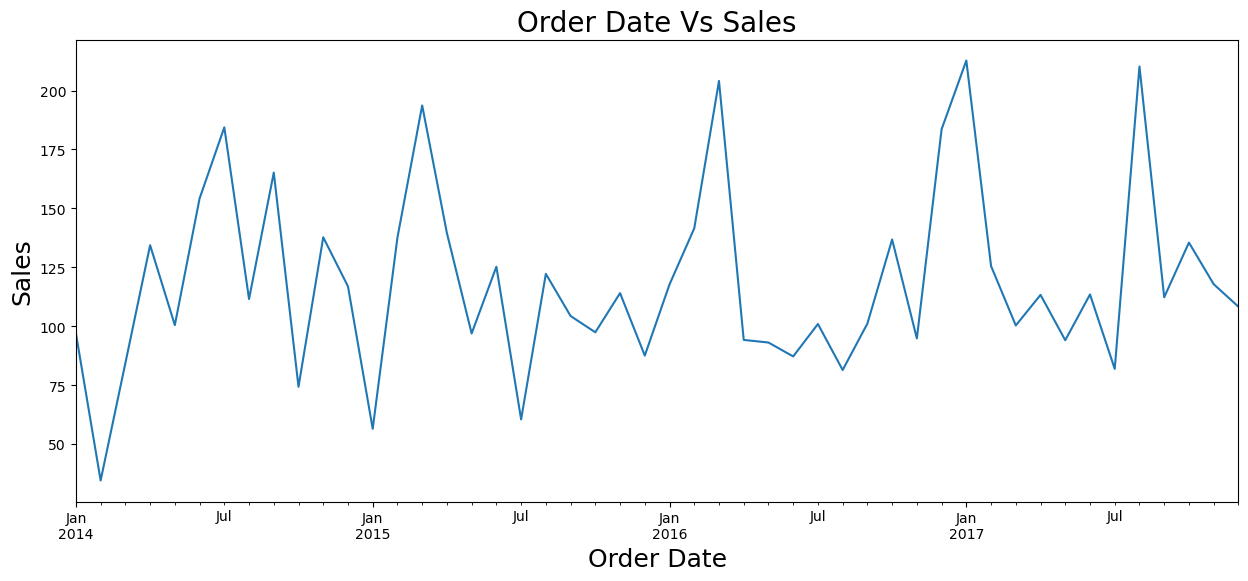

In [73]:
os_y.plot(figsize=(15,6))
plt.ylabel("Sales",fontsize=18)
plt.xlabel("Order Date",fontsize=18)
plt.title("Order Date Vs Sales",fontsize=20)
plt.show()

In [74]:
decomposition_os = sm.tsa.seasonal_decompose(os_y,model='additive')

<function matplotlib.pyplot.show(close=None, block=None)>

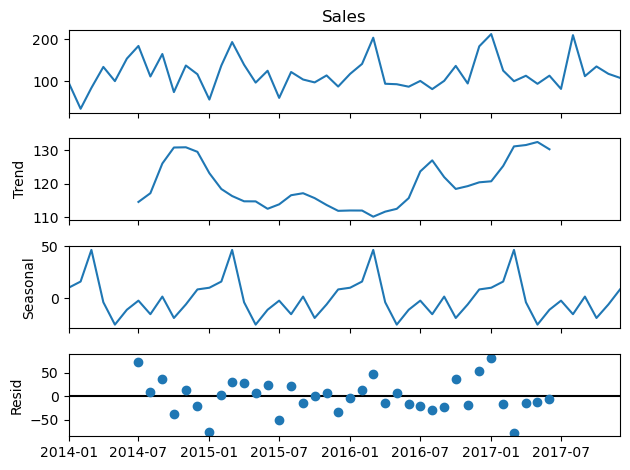

In [75]:
fig = decomposition_os.plot()
plt.show

In [76]:
p=d=q=range(0,2)
pdq = list(itertools.product(p,d,q))
seasonal_pdq = [(x[1],x[1],x[1], 12) for x in pdq]

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(os_y,order = param, seasonal_order = param_seasonal ,
                                            enforce_stationarity= False , enforce_invertibility= False )
            results = mod.fit()
            
            print('ARIMA{} x {} 12 -- AIC : {}'.format(param, param_seasonal, results.aic))
            
        except:
             continue

ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 589.5002315061224
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 589.5002315061224


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 250.10262158199632


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(0, 0, 0) x (1, 1, 1, 12) 12 -- AIC : 250.10262158199632
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 589.5002315061224
ARIMA(0, 0, 0) x (0, 0, 0, 12) 12 -- AIC : 589.5002315061224


...

ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 235.53068980339572
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 467.41493158573996
ARIMA(1, 1, 1) x (0, 0, 0, 12) 12 -- AIC : 467.41493158573996


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 235.53068980339572


C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(1, 1, 1) x (1, 1, 1, 12) 12 -- AIC : 235.53068980339572


In [77]:
mod_os = sm.tsa.statespace.SARIMAX(os_y,
                               order=(1,1,1),
                               seasonal_order= (1,1,1,12),
                               enforce_stationarity = False,
                               enforce_invertibility=False)

results_os = mod_os.fit()

C:\Users\01\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [78]:
print(results_os.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0328      0.301      0.109      0.913      -0.557       0.623
ma.L1         -1.0000      0.453     -2.205      0.027      -1.889      -0.111
ar.S.L12    -3.75e-05      0.561  -6.68e-05      1.000      -1.100       1.100
ma.S.L12      -0.5499      0.613     -0.897      0.370      -1.751       0.651
sigma2      2400.5577      0.000   1.27e+07      0.000    2400.557    2400.558


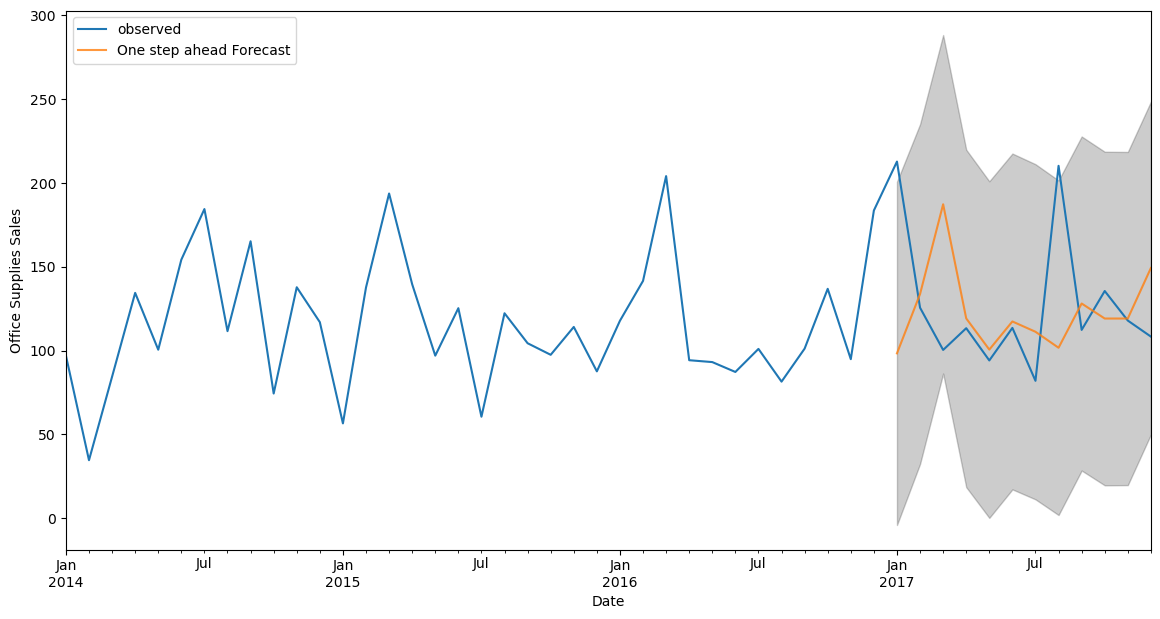

In [79]:
pred_os = results_os.get_prediction(start = pd.to_datetime('2017-01-01'), dynamic = False)
pred_ci_os = pred_os.conf_int()

ax = os_y['2014':].plot(label= 'observed')

pred_os.predicted_mean.plot(ax = ax, label = 'One step ahead Forecast',
                        alpha = 0.8, figsize= (14,7))

ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color = 'k', alpha= 0.2)

ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')
plt.legend()

plt.show()

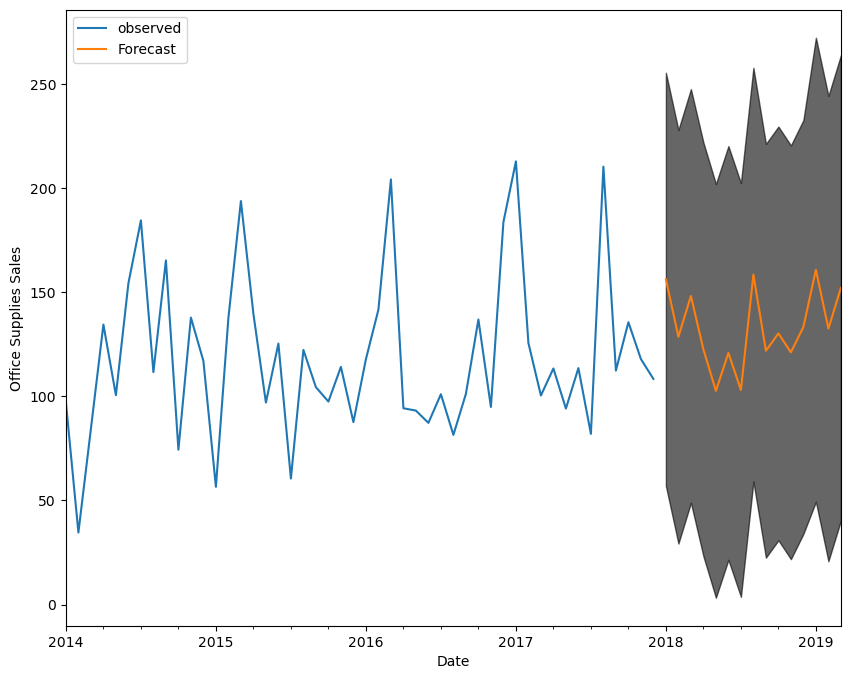

In [80]:
pred_uc_os = results.get_forecast(steps = 15)
pred_ci_os = pred_uc_os.conf_int()

ax = os_y.plot(label='observed', figsize=(10,8))
pred_uc_os.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')

plt.legend()
plt.show()

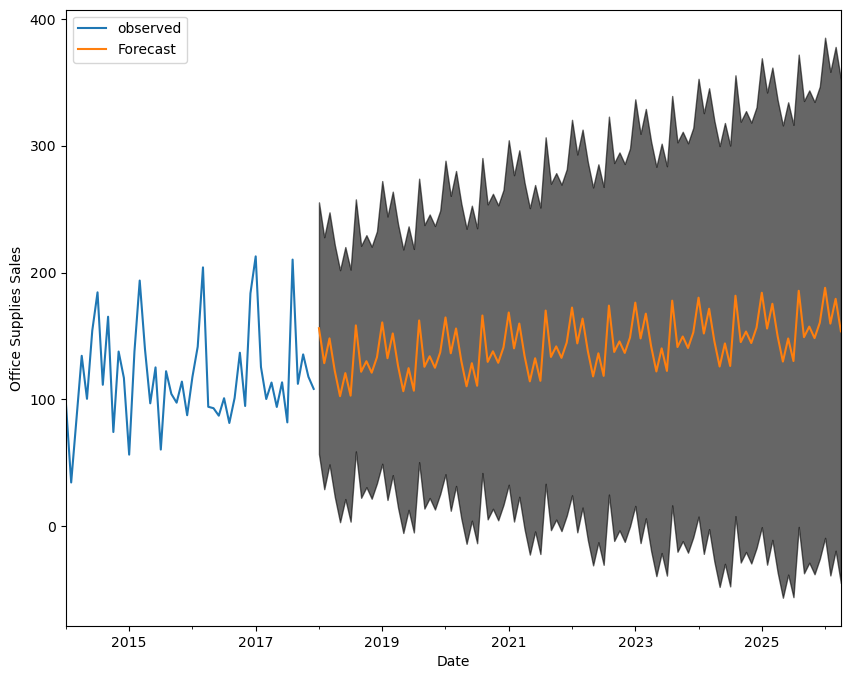

In [81]:
pred_uc_os = results.get_forecast(steps = 100)
pred_ci_os = pred_uc_os.conf_int()

ax = os_y.plot(label='observed', figsize=(10,8))
pred_uc_os.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')

plt.legend()
plt.show()

In [82]:
predictions = results_os.get_forecast(steps=100)
predicted_m = predictions.predicted_mean
print(predicted_m)  

2018-01-01    156.128424
2018-02-01    128.552579
2018-03-01    148.143683
2018-04-01    122.509536
2018-05-01    102.577331
                 ...    
2025-12-01    160.525913
2026-01-01    187.986728
2026-02-01    159.742106
2026-03-01    179.309699
2026-04-01    153.676285
Freq: MS, Name: predicted_mean, Length: 100, dtype: float64


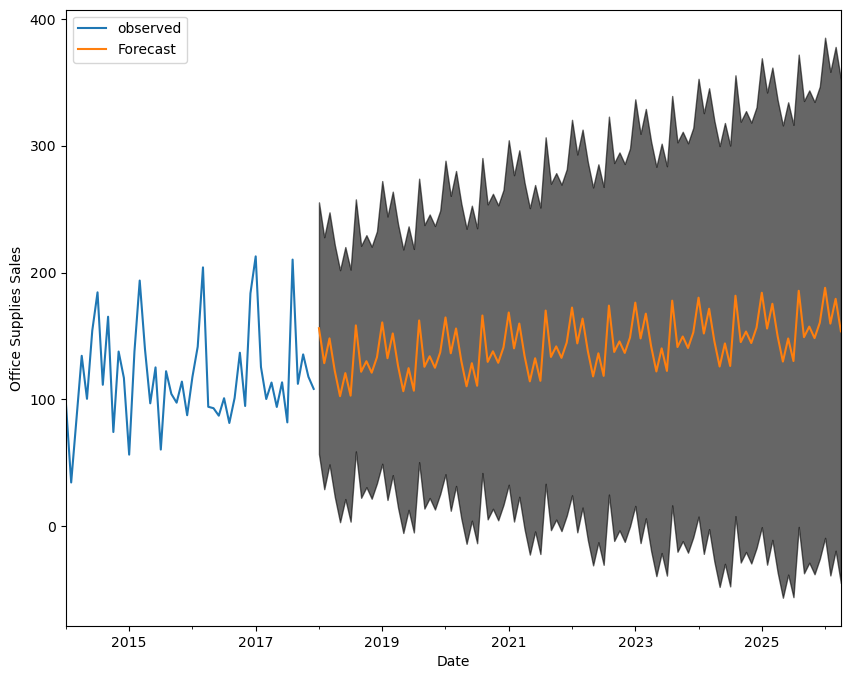

In [83]:
ax = os_y.plot(label='observed', figsize=(10,8))
predicted_m.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci_os.index,
               pred_ci_os.iloc[:,0],
               pred_ci_os.iloc[:,1],color='k',alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Office Supplies Sales')

plt.legend()
plt.show()

## Forcasting Values

In [84]:
pred_o = results_os.get_forecast(steps=100)
pred_office = pred_o.predicted_mean
print(pred_office)  

2018-01-01    156.128424
2018-02-01    128.552579
2018-03-01    148.143683
2018-04-01    122.509536
2018-05-01    102.577331
                 ...    
2025-12-01    160.525913
2026-01-01    187.986728
2026-02-01    159.742106
2026-03-01    179.309699
2026-04-01    153.676285
Freq: MS, Name: predicted_mean, Length: 100, dtype: float64


In [85]:
# Create future dates
future_date = pd.date_range(start=os_y.tail().index[-1], periods=100+1, freq='M')[1:]

C:\Users\01\AppData\Local\Temp\ipykernel_8096\687336195.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_date = pd.date_range(start=os_y.tail().index[-1], periods=100+1, freq='M')[1:]


In [86]:
print(future_date)

DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31',
               '2019-01-31', '2019-02-28', '2019-03-31', '2019-04-30',
               '2019-05-31', '2019-06-30', '2019-07-31', '2019-08-31',
               '2019-09-30', '2019-10-31', '2019-11-30', '2019-12-31',
               '2020-01-31', '2020-02-29', '2020-03-31', '2020-04-30',
               '2020-05-31', '2020-06-30', '2020-07-31', '2020-08-31',
               '2020-09-30', '2020-10-31', '2020-11-30', '2020-12-31',
               '2021-01-31', '2021-02-28', '2021-03-31', '2021-04-30',
               '2021-05-31', '2021-06-30', '2021-07-31', '2021-08-31',
               '2021-09-30', '2021-10-31', '2021-11-30', '2021-12-31',
               '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
      

In [87]:
# Convert forecast to DataFrame
forecast_office = pd.DataFrame({'Order Date': future_date, 'Sales': pred_office.values})
print(forecast_office)

   Order Date       Sales
0  2018-01-31  156.128424
1  2018-02-28  128.552579
2  2018-03-31  148.143683
3  2018-04-30  122.509536
4  2018-05-31  102.577331
..        ...         ...
95 2025-12-31  160.525913
96 2026-01-31  187.986728
97 2026-02-28  159.742106
98 2026-03-31  179.309699
99 2026-04-30  153.676285

[100 rows x 2 columns]


In [88]:
# Save forecast to CSV
forecast_office.to_csv("office_forcast.csv", index=False)

In [89]:
os_y.to_csv("office.csv", index=True)